c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


     PHASE 9: SHAP ANALYSIS LAYER & COMPLIANCE AUDITING            
[TRAINING] Fitting production LightGBM model for SHAP calculations...

[SHAP] Initializing TreeExplainer engine...


c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(



[VISUALIZATION] Rendering Global SHAP Summary Plot...


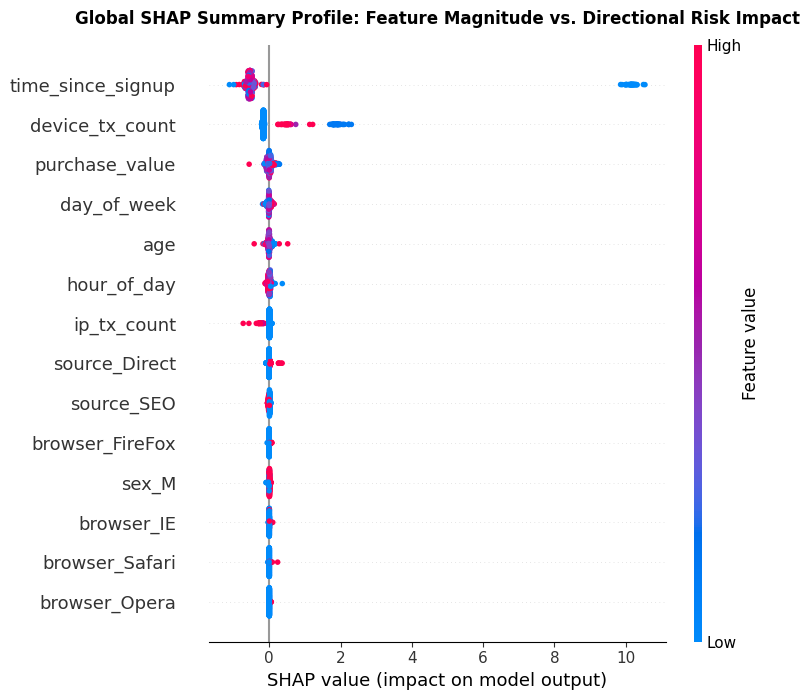


[AUDIT] Matrix Profiling: Detected 1491 TPs, 2 FPs, 1339 FNs in test slice.



------------------------------------------------------------
 GENERATING LOCAL EXPLAINER FORCE PLOT: TRUE POSITIVE (CORRECTLY FLAGGED FRAUD) (Row Index: 3366)
------------------------------------------------------------


c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


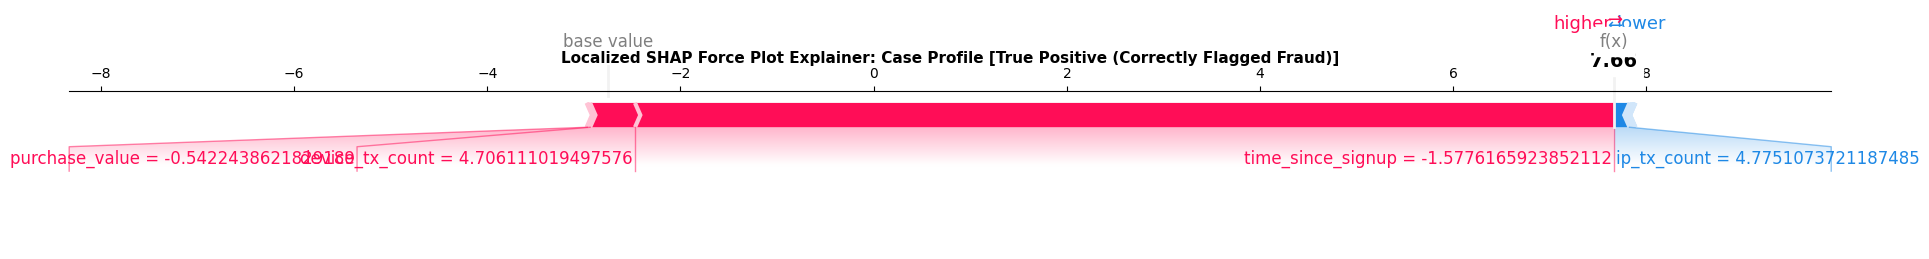

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(



------------------------------------------------------------
 GENERATING LOCAL EXPLAINER FORCE PLOT: FALSE POSITIVE (FALSE ALARM / HONEST USER FLAGGED) (Row Index: 116848)
------------------------------------------------------------


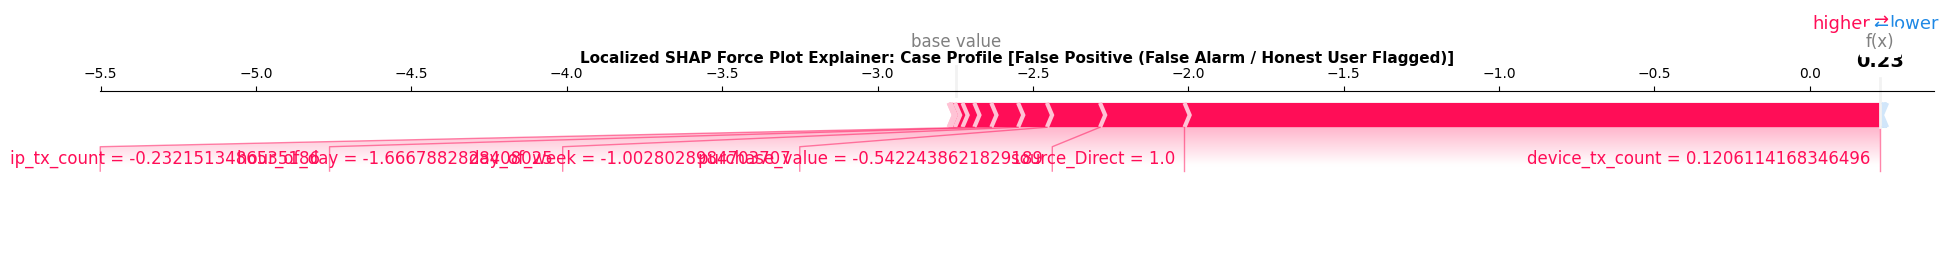

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(



------------------------------------------------------------
 GENERATING LOCAL EXPLAINER FORCE PLOT: FALSE NEGATIVE (MISSED FRAUD SLIP) (Row Index: 139427)
------------------------------------------------------------


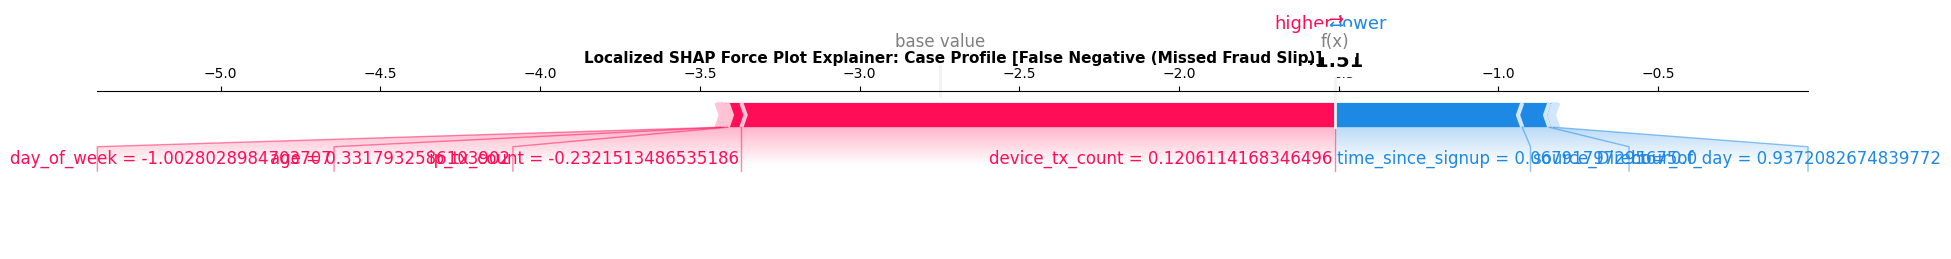

In [1]:
import os
import sys
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Ensure the SHAP framework is installed in your active environment
try:
    import shap
except ImportError:
    print("[ENV] Installing missing framework: shap...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap

from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier

print("==================================================================")
print("     PHASE 9: SHAP ANALYSIS LAYER & COMPLIANCE AUDITING            ")
print("==================================================================")

# --- RECOVERY ENGINE: LOAD DATA AND TRAIN WORKSPACE MODEL ---
PROCESSED_DIR = "../data/processed"
ECOM_PATH = os.path.join(PROCESSED_DIR, "ecommerce_final_ml.csv")

if not os.path.exists(ECOM_PATH):
    raise FileNotFoundError(f"[ERROR] Cleaned processed dataset missing at {ECOM_PATH}. Run previous data stages first.")

# We pull the E-Commerce stream for this demo, as its features represent clear human behaviors 
# (e.g., signup-to-purchase latency, device velocity, transaction amounts).
ecom_df = pd.read_csv(ECOM_PATH)
X = ecom_df.drop(columns=['class'])
y = ecom_df['class'].astype(np.int8)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Fit production LightGBM model
print("[TRAINING] Fitting production LightGBM model for SHAP calculations...")
model = LGBMClassifier(n_estimators=150, max_depth=6, num_leaves=31, learning_rate=0.05, random_state=42, n_jobs=-1, verbosity=-1)
model.fit(X_train, y_train)

# --- 2. COMPUTE GLOBAL SHAP VALUES USING TREE EXPLORER ---
print("\n[SHAP] Initializing TreeExplainer engine...")
explainer = shap.TreeExplainer(model)

# To balance compute speed, we take a stratified sample of 500 test points to map out SHAP coordinates
X_test_sampled = X_test.sample(n=500, random_state=42)
shap_values = explainer.shap_values(X_test_sampled)

# Handle LightGBM multi-class probability extraction array mapping
# For binary classification, index [1] represents the log-odds change for the positive (Fraud) class
if isinstance(shap_values, list):
    # Depending on SHAP version, it may return a list for binary classifiers
    shap_v_positive = shap_values[1]
else:
    shap_v_positive = shap_values

# ==============================================================================
# SUB-TASK 1: GLOBAL SHAP SUMMARY PLOT
# ==============================================================================
print("\n[VISUALIZATION] Rendering Global SHAP Summary Plot...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_v_positive, X_test_sampled, show=False)
plt.title("Global SHAP Summary Profile: Feature Magnitude vs. Directional Risk Impact", fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# ==============================================================================
# SUB-TASK 2: TARGET LOCALIZED FORCE PLOT ISOLATIONS
# ==============================================================================
# Generate class predictions across the complete test matrix to isolate performance anomalies
y_pred = model.predict(X_test)

# Map row indices matching specific operational anomalies
df_eval = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}, index=X_test.index)

true_positives = df_eval[(df_eval['Actual'] == 1) & (df_eval['Predicted'] == 1)]
false_positives = df_eval[(df_eval['Actual'] == 0) & (df_eval['Predicted'] == 1)]
false_negatives = df_eval[(df_eval['Actual'] == 1) & (df_eval['Predicted'] == 0)]

print(f"\n[AUDIT] Matrix Profiling: Detected {len(true_positives)} TPs, {len(false_positives)} FPs, {len(false_negatives)} FNs in test slice.")

# Initialize standard javascript visualization layer for inline plots
shap.initjs()

def generate_local_force_plot(row_index, case_name):
    """Calculates and renders a localized post-hoc force plot explanation for a single transaction row."""
    target_row = X_test.loc[[row_index]]
    row_shap_values = explainer.shap_values(target_row)
    
    # Extract structural positive log-odds coordinate matrix
    row_shap_pos = row_shap_values[1] if isinstance(row_shap_values, list) else row_shap_values
    base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

    print(f"\n" + "-"*60)
    print(f" GENERATING LOCAL EXPLAINER FORCE PLOT: {case_name.upper()} (Row Index: {row_index})")
    print("-"*60)
    
    # Render static force plot via matplotlib for notebook compatibility
    shap.force_plot(
        base_value, 
        row_shap_pos[0], 
        target_row.iloc[0], 
        matplotlib=True, 
        show=False
    )
    plt.title(f"Localized SHAP Force Plot Explainer: Case Profile [{case_name}]", fontsize=11, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

# Execute Force Plots across all 3 specific compliance cases
if not true_positives.empty:
    generate_local_force_plot(true_positives.index[0], "True Positive (Correctly Flagged Fraud)")
else:
    print("[WARNING] Zero True Positive rows available in test split layout.")

if not false_positives.empty:
    generate_local_force_plot(false_positives.index[0], "False Positive (False Alarm / Honest User Flagged)")
else:
    print("[WARNING] Zero False Positive rows available in test split layout.")

if not false_negatives.empty:
    generate_local_force_plot(false_negatives.index[0], "False Negative (Missed Fraud Slip)")
else:
    print("[WARNING] Zero False Negative rows available in test split layout.")